# Threshold Explorer — what cutoff should I actually use?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/threshold-explorer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/threshold-explorer/demo.ipynb)

A classifier outputs a probability. A *decision* needs a cutoff. Almost every model ships
with `0.5` — a number nobody chose, that quietly assumes a false positive and a false
negative hurt exactly the same amount. They almost never do.

This notebook sweeps every cutoff and shows that **four defensible answers disagree** on
the same model and the same data.

**Contents**
1. Sample data — an imbalanced, fraud-style problem
2. The sweep — every cutoff, scored
3. Four cutoffs, four different numbers
4. Visualising the tradeoff (metrics curve + cost curve)
5. Hard floors: when an SLA is simply unreachable
6. Summary table
7. Try your own scores

## 1. Sample data

4,000 transactions, ~8% fraudulent, scored by a decent-but-imperfect model. The score
distributions **overlap** — which is the whole reason a cutoff is a hard choice. If they
were cleanly separated, any threshold in the gap would do and this tool would be pointless.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


@dataclass
class Point:
    """Everything you need to judge one operating point."""

    threshold: float
    tp: int
    fp: int
    fn: int
    tn: int

    @property
    def precision(self) -> float:
        d = self.tp + self.fp
        return self.tp / d if d else 0.0

    @property
    def recall(self) -> float:
        d = self.tp + self.fn
        return self.tp / d if d else 0.0

    @property
    def specificity(self) -> float:
        d = self.tn + self.fp
        return self.tn / d if d else 0.0

    @property
    def f1(self) -> float:
        p, r = self.precision, self.recall
        return 2 * p * r / (p + r) if (p + r) else 0.0

    @property
    def accuracy(self) -> float:
        n = self.tp + self.fp + self.fn + self.tn
        return (self.tp + self.tn) / n if n else 0.0

    @property
    def flag_rate(self) -> float:
        """Share of the population this cutoff sends downstream (review queue size)."""
        n = self.tp + self.fp + self.fn + self.tn
        return (self.tp + self.fp) / n if n else 0.0

    def cost(self, cost_fp: float, cost_fn: float) -> float:
        return self.fp * cost_fp + self.fn * cost_fn

    def as_row(self, cost_fp: float = 1.0, cost_fn: float = 1.0) -> Dict[str, float]:
        return {
            "threshold": round(self.threshold, 4),
            "precision": round(self.precision, 4),
            "recall": round(self.recall, 4),
            "f1": round(self.f1, 4),
            "flag_rate": round(self.flag_rate, 4),
            "tp": self.tp,
            "fp": self.fp,
            "fn": self.fn,
            "tn": self.tn,
            "cost": round(self.cost(cost_fp, cost_fn), 2),
        }


def sample_scores(n: int = 4000, prevalence: float = 0.08, seed: int = 42):
    """Imbalanced fraud-style sample: 8% positives, heavy score overlap."""
    rng = np.random.default_rng(seed)
    y = (rng.random(n) < prevalence).astype(int)
    score = np.where(y == 1, rng.beta(5.0, 2.6, size=n), rng.beta(2.0, 6.5, size=n))
    return y, np.clip(score, 0.0, 1.0)


y_true, y_score = sample_scores()
print(f"rows            : {len(y_true):,}")
print(f"positives       : {y_true.sum():,} ({y_true.mean():.2%})")
print(f"mean score | y=1: {y_score[y_true == 1].mean():.3f}")
print(f"mean score | y=0: {y_score[y_true == 0].mean():.3f}")

rows            : 4,000
positives       : 310 (7.75%)
mean score | y=1: 0.664
mean score | y=0: 0.236


## 2. The sweep

For every candidate cutoff we predict positive when `score >= threshold`, then count the
four confusion-matrix cells. Everything else — precision, recall, F1, flag rate, cost —
is derived from those four numbers.

We also compute ROC AUC, which is *threshold-free*: it measures how well the model
**ranks**, and deliberately says nothing about where to cut. A high AUC and a badly chosen
threshold is a very common, very expensive combination.

In [2]:
def sweep(y_true, y_score, n_steps: int = 101) -> List[Point]:
    yt = np.asarray(y_true, dtype=float)
    ys = np.asarray(y_score, dtype=float)
    if yt.size != ys.size:
        raise ValueError("Length mismatch between labels and scores.")
    if yt.sum() in (0, yt.size):
        raise ValueError("y_true has only one class — a sweep is meaningless.")
    out: List[Point] = []
    for t in np.linspace(0.0, 1.0, n_steps):
        pred = ys >= t
        out.append(
            Point(
                threshold=float(t),
                tp=int(np.sum(pred & (yt == 1))),
                fp=int(np.sum(pred & (yt == 0))),
                fn=int(np.sum(~pred & (yt == 1))),
                tn=int(np.sum(~pred & (yt == 0))),
            )
        )
    return out


def roc_auc(y_true, y_score) -> float:
    """Threshold-free ranking quality, via the Mann-Whitney U identity."""
    yt = np.asarray(y_true, dtype=float)
    ys = np.asarray(y_score, dtype=float)
    order = np.argsort(ys, kind="mergesort")
    ranks = np.empty(ys.size, dtype=float)
    ranks[order] = np.arange(1, ys.size + 1, dtype=float)
    uniq, inv, counts = np.unique(ys, return_inverse=True, return_counts=True)
    sums = np.zeros(uniq.size)
    np.add.at(sums, inv, ranks)
    ranks = (sums / counts)[inv]
    n_pos, n_neg = float(yt.sum()), float((1 - yt).sum())
    return float((ranks[yt == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


points = sweep(y_true, y_score)
print(f"cutoffs evaluated : {len(points)}")
print(f"ROC AUC           : {roc_auc(y_true, y_score):.4f}  (ranking is good...)")
print("...but AUC never tells you where to cut. That is the next section.")

cutoffs evaluated : 101
ROC AUC           : 0.9707  (ranking is good...)
...but AUC never tells you where to cut. That is the next section.


## 3. Four cutoffs, four different numbers

Each of these is a *correct* answer to a *different* question:

| Cutoff | The question it answers |
|---|---|
| **0.50** | "What does the library do by default?" |
| **Best F1** | "What balances precision and recall?" — assumes both errors cost the same |
| **Cheapest** | "What loses the least money?" — here a missed fraud costs 20x a false alarm |
| **Precision floor** | "What is the best recall I can get while keeping the review queue clean?" |

Watch how far apart they land.

In [3]:
def best_by(points: List[Point], metric: str = "f1") -> Point:
    return max(points, key=lambda p: getattr(p, metric))


def min_cost(points: List[Point], cost_fp: float, cost_fn: float) -> Point:
    return min(points, key=lambda p: p.cost(cost_fp, cost_fn))


def under_constraint(points, floor_metric, floor_value, maximize, min_flags: int = 30):
    """Best `maximize` among cutoffs clearing a hard floor. None = SLA unreachable.

    `min_flags` blocks the classic trap: flag 3 rows, get all 3 right, report
    "precision 1.00". That is a small sample, not an operating point.
    """
    feasible = [
        p
        for p in points
        if getattr(p, floor_metric) >= floor_value and (p.tp + p.fp) >= min_flags
    ]
    return max(feasible, key=lambda p: getattr(p, maximize)) if feasible else None


COST_FP, COST_FN = 1.0, 20.0   # annoying a good customer vs. eating a fraud loss

default = min(points, key=lambda p: abs(p.threshold - 0.5))
f1_best = best_by(points, "f1")
cheapest = min_cost(points, COST_FP, COST_FN)
sla = under_constraint(points, "precision", 0.80, "recall")

chosen = {
    "Default 0.50": default,
    "Best F1": f1_best,
    f"Cheapest (FP={COST_FP:g}, FN={COST_FN:g})": cheapest,
    "Precision >= 0.80": sla,
}

for label, p in chosen.items():
    print(
        f"{label:<32} threshold={p.threshold:.2f}  "
        f"precision={p.precision:.3f}  recall={p.recall:.3f}  "
        f"flags={p.flag_rate:.1%}  cost={p.cost(COST_FP, COST_FN):>7,.0f}"
    )

saved = default.cost(COST_FP, COST_FN) - cheapest.cost(COST_FP, COST_FN)
print(
    f"\nShipping 0.50 instead of {cheapest.threshold:.2f} costs an extra "
    f"{saved:,.0f} units — {saved / default.cost(COST_FP, COST_FN):.1%} more than necessary."
)

Default 0.50                     threshold=0.50  precision=0.595  recall=0.845  flags=11.0%  cost=  1,138
Best F1                          threshold=0.55  precision=0.724  recall=0.771  flags=8.2%  cost=  1,511
Cheapest (FP=1, FN=20)           threshold=0.41  precision=0.396  recall=0.948  flags=18.6%  cost=    768
Precision >= 0.80                threshold=0.59  precision=0.800  recall=0.684  flags=6.6%  cost=  2,013

Shipping 0.50 instead of 0.41 costs an extra 370 units — 32.5% more than necessary.


## 4. Seeing the tradeoff

Three panels tell the whole story:

- **Left** — the score distributions overlap, so no cutoff separates the classes cleanly.
- **Middle** — precision climbs and recall falls as the cutoff rises. F1 peaks somewhere in
  the middle, but that peak is only "best" if your two error types cost the same.
- **Right** — the cost curve, once false negatives are priced at 20x. Its minimum sits
  **below** 0.5: when misses are expensive, you should flag *more* aggressively, not less.

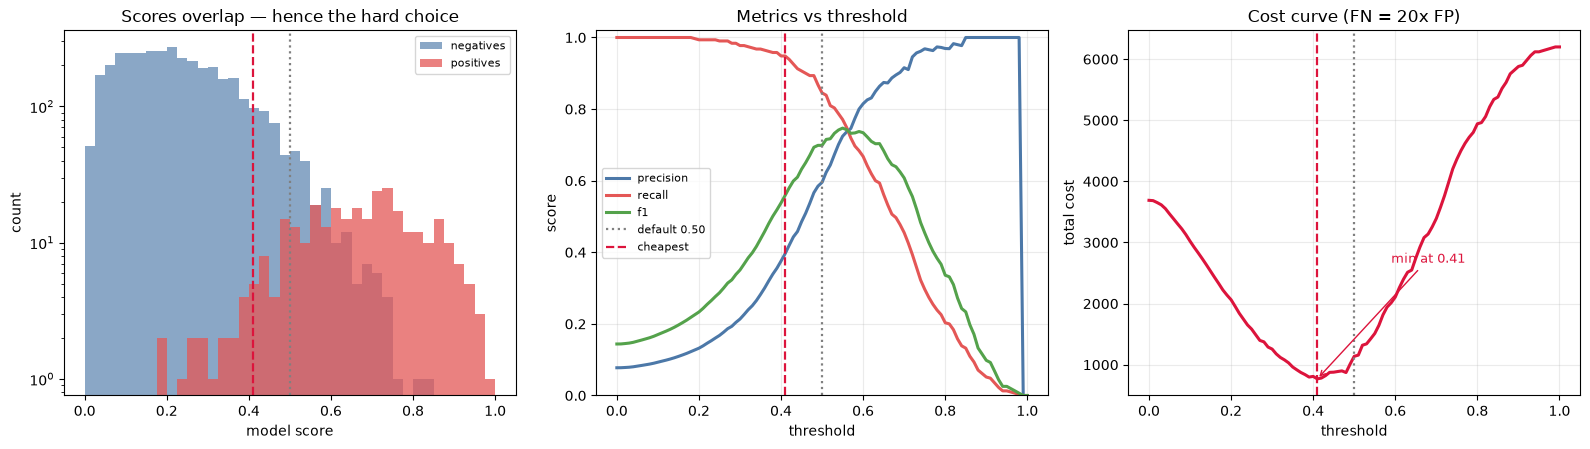

In [4]:
thr = [p.threshold for p in points]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# --- score distributions -------------------------------------------------
ax = axes[0]
bins = np.linspace(0, 1, 41)
ax.hist(y_score[y_true == 0], bins=bins, alpha=0.65, label="negatives", color="#4C78A8")
ax.hist(y_score[y_true == 1], bins=bins, alpha=0.75, label="positives", color="#E45756")
ax.axvline(0.5, color="grey", ls=":", lw=1.6)
ax.axvline(cheapest.threshold, color="crimson", ls="--", lw=1.6)
ax.set(xlabel="model score", ylabel="count", title="Scores overlap — hence the hard choice")
ax.set_yscale("log")
ax.legend(fontsize=8)

# --- metrics vs threshold ------------------------------------------------
ax = axes[1]
for name, vals, c in [
    ("precision", [p.precision for p in points], "#4C78A8"),
    ("recall", [p.recall for p in points], "#E45756"),
    ("f1", [p.f1 for p in points], "#54A24B"),
]:
    ax.plot(thr, vals, label=name, lw=2.2, color=c)
ax.axvline(0.5, color="grey", ls=":", lw=1.6, label="default 0.50")
ax.axvline(cheapest.threshold, color="crimson", ls="--", lw=1.6, label="cheapest")
ax.set(xlabel="threshold", ylabel="score", title="Metrics vs threshold", ylim=(0, 1.02))
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# --- cost curve ----------------------------------------------------------
ax = axes[2]
costs = [p.cost(COST_FP, COST_FN) for p in points]
ax.plot(thr, costs, lw=2.2, color="crimson")
ax.axvline(0.5, color="grey", ls=":", lw=1.6)
ax.axvline(cheapest.threshold, color="crimson", ls="--", lw=1.6)
ax.annotate(
    f"min at {cheapest.threshold:.2f}",
    xy=(cheapest.threshold, min(costs)),
    xytext=(cheapest.threshold + 0.18, min(costs) + 0.35 * (max(costs) - min(costs))),
    arrowprops=dict(arrowstyle="->", color="crimson"),
    fontsize=9,
    color="crimson",
)
ax.set(xlabel="threshold", ylabel="total cost", title=f"Cost curve (FN = {COST_FN:g}x FP)")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("threshold_explorer.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. When the SLA is unreachable

A hard floor ("precision must be at least X, or the review team drowns") has three possible
outcomes, and the third one is the useful one:

1. Plenty of cutoffs clear it — pick the one maximising recall.
2. Exactly one clears it — no choice to make.
3. **Nothing clears it** — the model cannot meet that promise at *any* cutoff. That is a
   retrain-or-renegotiate signal, not a tuning problem. Finding this out from a sweep takes
   a second; finding it out in production takes a quarter.

One guard matters here. Push the cutoff high enough and you flag three rows, get all three
right, and "achieve" precision 1.00. That is a small sample wearing a metric's clothes, so
`min_flags` throws out any cutoff that flags too few rows to mean anything.

In [5]:
def report_floors(pts: List[Point], label: str) -> None:
    print(label)
    for floor in [0.60, 0.80, 0.90, 0.97]:
        p = under_constraint(pts, "precision", floor, "recall")
        if p is None:
            print(f"  precision >= {floor:.2f}  ->  UNREACHABLE at any cutoff")
        else:
            print(
                f"  precision >= {floor:.2f}  ->  cutoff {p.threshold:.2f}, "
                f"recall {p.recall:.3f}, catches {p.tp} of {p.tp + p.fn} positives"
            )


report_floors(points, "Current model (AUC 0.97) — every floor is reachable, at a price:")

# The same exercise against a weaker model: noisier scores, much less separation.
rng = np.random.default_rng(7)
weak_score = np.clip(0.30 * y_score + 0.70 * rng.random(y_score.size), 0, 1)
weak_points = sweep(y_true, weak_score)
print()
report_floors(
    weak_points, f"Weaker model (AUC {roc_auc(y_true, weak_score):.2f}) — the ceiling bites:"
)
print(
    "\nThat UNREACHABLE line is the most valuable output here. No amount of threshold\n"
    "tuning buys precision the model does not have — the fix is features or training data."
)

Current model (AUC 0.97) — every floor is reachable, at a price:
  precision >= 0.60  ->  cutoff 0.51, recall 0.839, catches 260 of 310 positives
  precision >= 0.80  ->  cutoff 0.59, recall 0.684, catches 212 of 310 positives
  precision >= 0.90  ->  cutoff 0.69, recall 0.477, catches 148 of 310 positives
  precision >= 0.97  ->  cutoff 0.78, recall 0.239, catches 74 of 310 positives

Weaker model (AUC 0.68) — the ceiling bites:
  precision >= 0.60  ->  cutoff 0.80, recall 0.168, catches 52 of 310 positives
  precision >= 0.80  ->  UNREACHABLE at any cutoff
  precision >= 0.90  ->  UNREACHABLE at any cutoff
  precision >= 0.97  ->  UNREACHABLE at any cutoff

That UNREACHABLE line is the most valuable output here. No amount of threshold
tuning buys precision the model does not have — the fix is features or training data.


## 6. Summary

The model never changed. The data never changed. Only the *question* changed — and the
right cutoff moved with it. That is the entire argument for never shipping 0.5 by reflex.

In [6]:
summary = pd.DataFrame(
    [{"strategy": k, **v.as_row(COST_FP, COST_FN)} for k, v in chosen.items()]
)
summary = summary[
    ["strategy", "threshold", "precision", "recall", "f1", "flag_rate", "fp", "fn", "cost"]
]
print(summary.to_string(index=False))
print(
    f"\nSpread between the cheapest and the strictest cutoff: "
    f"{max(p.threshold for p in chosen.values()) - min(p.threshold for p in chosen.values()):.2f} "
    "— on identical predictions."
)
summary

              strategy  threshold  precision  recall     f1  flag_rate  fp  fn   cost
          Default 0.50       0.50     0.5955  0.8452 0.6987     0.1100 178  48 1138.0
               Best F1       0.55     0.7242  0.7710 0.7469     0.0825  91  71 1511.0
Cheapest (FP=1, FN=20)       0.41     0.3962  0.9484 0.5589     0.1855 448  16  768.0
     Precision >= 0.80       0.59     0.8000  0.6839 0.7374     0.0663  53  98 2013.0

Spread between the cheapest and the strictest cutoff: 0.18 — on identical predictions.


,strategy,threshold,precision,recall,f1,flag_rate,fp,fn,cost
0,Default 0.50,0.50,0.5955,0.8452,0.6987,0.1100,178,48,1138.0
1,Best F1,0.55,0.7242,0.7710,0.7469,0.0825,91,71,1511.0
2,"Cheapest (FP=1, FN=20)",0.41,0.3962,0.9484,0.5589,0.1855,448,16,768.0
3,Precision >= 0.80,0.59,0.8000,0.6839,0.7374,0.0663,53,98,2013.0


## 7. Try your own scores

Swap in real predictions — anything with a 0/1 label column and a probability column.

```python
# df = pd.read_csv("my_predictions.csv")          # needs y_true (0/1) and y_score (0-1)
# points = sweep(df["y_true"], df["y_score"])
#
# COST_FP, COST_FN = 5.0, 250.0                    # price YOUR errors, in your own units
# print("cheapest cutoff :", min_cost(points, COST_FP, COST_FN).as_row(COST_FP, COST_FN))
# print("best F1 cutoff  :", best_by(points, "f1").as_row())
# print("recall >= 0.95  :", under_constraint(points, "recall", 0.95, "precision"))
```

Two habits worth keeping: tune the threshold on **validation** data, never on test, and
re-check it whenever prevalence shifts — a cutoff tuned at 8% fraud misbehaves at 2%.

---

**Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** —
Day 122, ML Engineering Toolkit.

Prefer clicking to coding? The Streamlit version uploads a CSV, exposes the cost and SLA
inputs as sliders, and downloads the full sweep:

```bash
pip install -r requirements.txt
streamlit run app.py
```